In [7]:
from obb_anns import OBBAnns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
from PIL import Image
import os

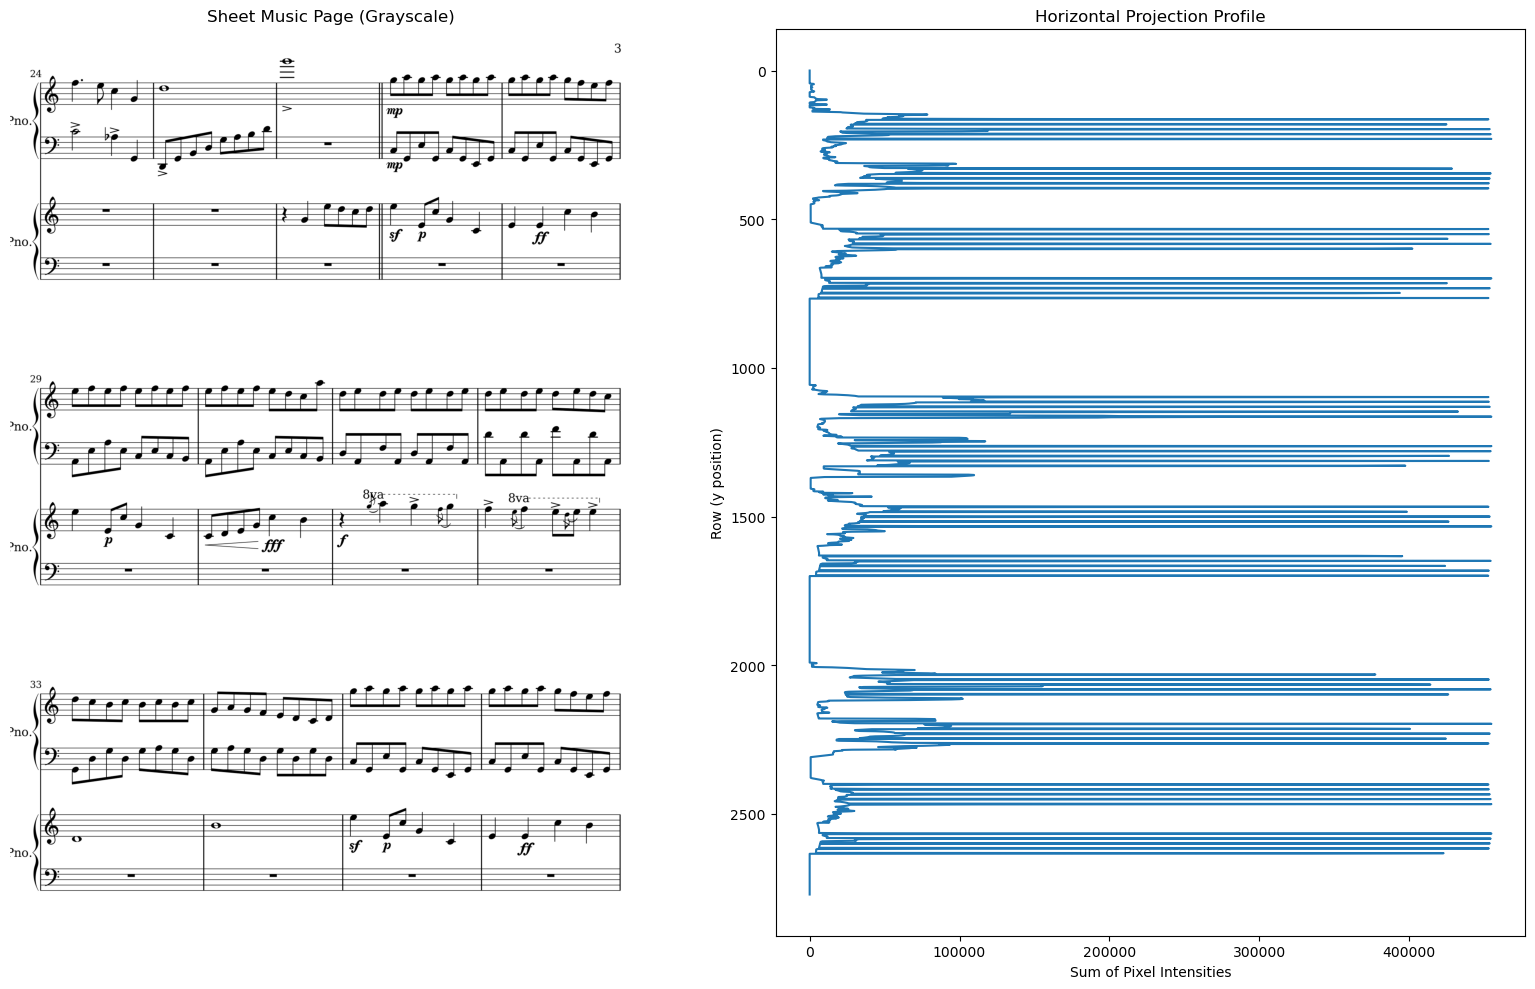

In [8]:
# Load one training image
sample_img_info = train.img_info[0]
img_path = f'../data/ds2_dense/images/{sample_img_info["filename"]}'
img = np.array(Image.open(img_path).convert('L'))  # grayscale

# Invert so staff lines are bright (high values)
img_inv = 255 - img

# Horizontal projection profile — sum across columns
projection = np.sum(img_inv, axis=1)

# Plot image alongside its projection profile
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Sheet Music Page (Grayscale)')
axes[0].axis('off')

axes[1].plot(projection, np.arange(len(projection)))
axes[1].invert_yaxis()
axes[1].set_title('Horizontal Projection Profile')
axes[1].set_xlabel('Sum of Pixel Intensities')
axes[1].set_ylabel('Row (y position)')

plt.tight_layout()
plt.show()

Detected 60 staff lines


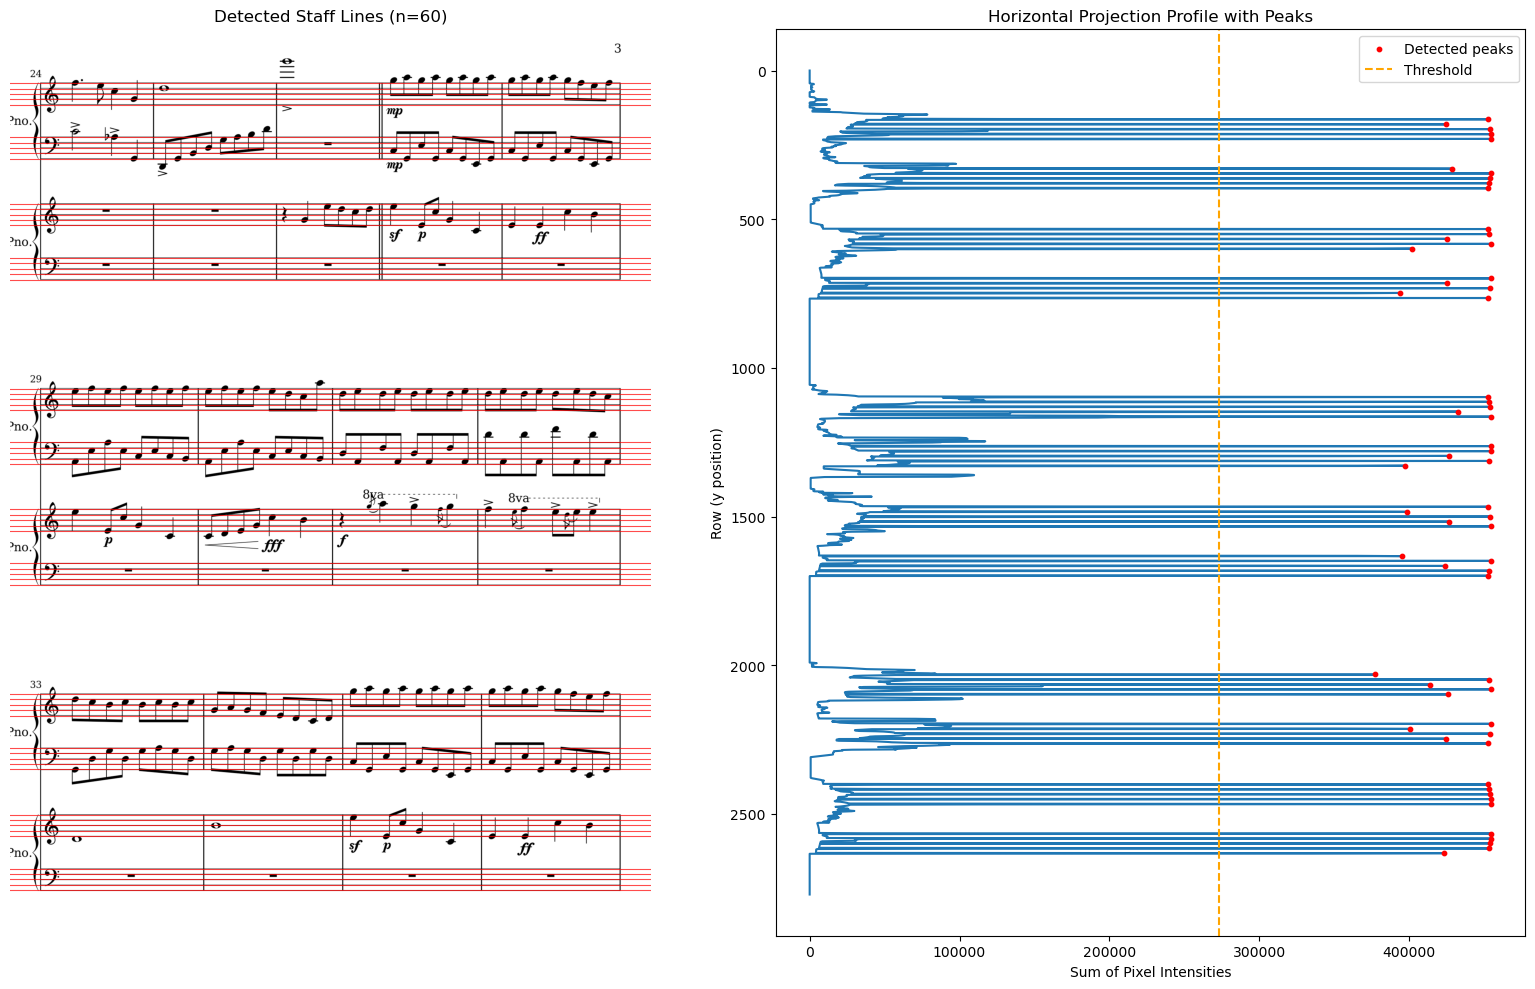

In [9]:
from scipy.signal import find_peaks

# Detect staff lines as peaks in the projection profile
# Staff lines are long horizontal black lines so they produce very high sums
threshold = np.max(projection) * 0.6  # peaks must be at least 60% of max
peaks, properties = find_peaks(projection, height=threshold, distance=5)

print(f"Detected {len(peaks)} staff lines")

# Plot with detected peaks overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Left: image with detected staff line positions marked
axes[0].imshow(img, cmap='gray')
for peak in peaks:
    axes[0].axhline(y=peak, color='red', linewidth=0.8, alpha=0.7)
axes[0].set_title(f'Detected Staff Lines (n={len(peaks)})')
axes[0].axis('off')

# Right: projection profile with peaks marked
axes[1].plot(projection, np.arange(len(projection)))
axes[1].scatter(projection[peaks], peaks, color='red', s=10, zorder=5, label='Detected peaks')
axes[1].axvline(x=threshold, color='orange', linestyle='--', label='Threshold')
axes[1].invert_yaxis()
axes[1].set_title('Horizontal Projection Profile with Peaks')
axes[1].set_xlabel('Sum of Pixel Intensities')
axes[1].set_ylabel('Row (y position)')
axes[1].legend()

plt.tight_layout()
plt.show()

Detected 12 staves

Staff positions (top and bottom line y-coordinates):
  Staff 1: y=164 to y=230 (height=66px)
  Staff 2: y=330 to y=396 (height=66px)
  Staff 3: y=533 to y=599 (height=66px)
  Staff 4: y=699 to y=765 (height=66px)
  Staff 5: y=1098 to y=1164 (height=66px)
  Staff 6: y=1263 to y=1329 (height=66px)
  Staff 7: y=1467 to y=1533 (height=66px)
  Staff 8: y=1633 to y=1699 (height=66px)
  Staff 9: y=2031 to y=2098 (height=67px)
  Staff 10: y=2197 to y=2263 (height=66px)
  Staff 11: y=2401 to y=2467 (height=66px)
  Staff 12: y=2566 to y=2632 (height=66px)


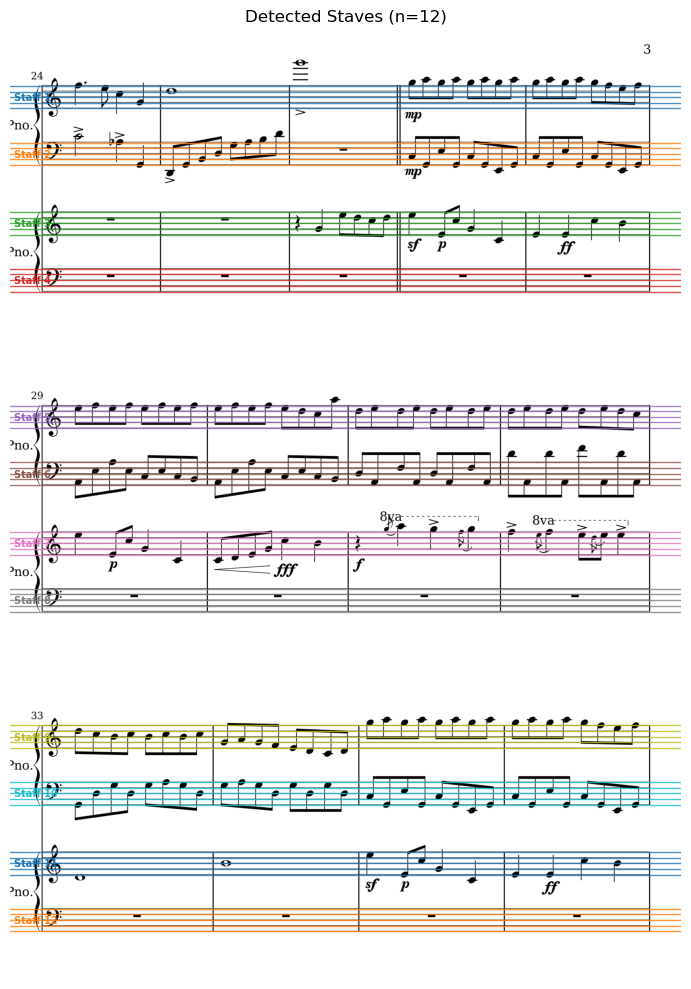

In [10]:
# Group detected staff lines into staves (every 5 lines = 1 staff)
staff_lines_grouped = [peaks[i:i+5] for i in range(0, len(peaks), 5)]

print(f"Detected {len(staff_lines_grouped)} staves")
print(f"\nStaff positions (top and bottom line y-coordinates):")
for i, staff in enumerate(staff_lines_grouped):
    if len(staff) == 5:
        print(f"  Staff {i+1}: y={staff[0]} to y={staff[4]} (height={staff[4]-staff[0]}px)")
    else:
        print(f"  Staff {i+1}: incomplete ({len(staff)} lines detected)")

# Visualize with staves colored and labeled
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img, cmap='gray')

colors = plt.cm.tab10.colors
for i, staff in enumerate(staff_lines_grouped):
    color = colors[i % len(colors)]
    for line in staff:
        ax.axhline(y=line, color=color, linewidth=1, alpha=0.8)
    if len(staff) == 5:
        mid = int(np.mean(staff))
        ax.text(10, mid, f'Staff {i+1}', color=color, fontsize=7, 
                verticalalignment='center', fontweight='bold')

ax.set_title(f'Detected Staves (n={len(staff_lines_grouped)})')
ax.axis('off')
plt.tight_layout()
plt.show()

## Initial Baseline: Staff Line Detection

As a first classical CV baseline, I implemented staff line detection using horizontal projection profiles which is a well known technique in optical music recognition.

- Method: Invert the grayscale image so staff lines become bright, sum pixel intensities across each row, then detect peaks above a threshold (60% of maximum). Lines are grouped into staves in sets of 5.

- Result: On the sample page above, all 60 staff lines were correctly detected (12 staves × 5 lines), with consistent staff heights of ~66px across the page.

- Why this matters: Staff line positions are the first step to figuring out the pitch of a note. Knowing where each staff is allows me to interpret the position of a note relative to the staff and map them to actual pitches (A–G). This baseline also establishes that classical CV techniques work well on this clean synthetic data.

- Limitations: This approach might struggle on real scanned sheet music with noise, skew, or degradation which confirms the necessity of the deep learning approach in check-in 2.

Source: https://ieeexplore.ieee.org/document/6628585